In [1]:
from google.colab import drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

project_path = "/content/drive/MyDrive/ResumeGPT"

# Load cleaned dataframe
df = pd.read_csv(project_path + "/data/processed/cleaned_resumes.csv")

# Fix empty rows
df['cleaned_resume'] = df['cleaned_resume'].fillna('')
df = df[df['cleaned_resume'] != ''].reset_index(drop=True)

print("DataFrame shape:", df.shape)

# ─── REBUILD X from scratch instead of loading saved matrix ───
# This ensures X and y have exactly the same number of rows
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

print("Rebuilding TF-IDF matrix... (takes ~30 seconds)")
X = vectorizer.fit_transform(df['cleaned_resume'])

# Labels
y = df['Category']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("✓ Both match! Ready for train_test_split")

DataFrame shape: (2483, 5)
Rebuilding TF-IDF matrix... (takes ~30 seconds)
X shape: (2483, 5000)
y shape: (2483,)
✓ Both match! Ready for train_test_split


In [8]:
import scipy.sparse

# Save corrected matrix and vectorizer
scipy.sparse.save_npz(project_path + "/data/processed/tfidf_matrix.npz", X)

with open(project_path + "/data/processed/tfidf_vectorizer.pkl", 'wb') as f:
    pickle.dump(vectorizer, f)

print("✓ Corrected files saved!")

✓ Corrected files saved!


In [7]:
# WHY 80/20?
# 80% of resumes = model learns from these
# 20% of resumes = we test the model on these (model has NEVER seen them)
# This tells us how well the model works on real-world NEW resumes

# Let's visualize this concept first
total = len(y)
train_size = int(total * 0.8)
test_size = total - train_size

print("=== Train/Test Split Plan ===")
print(f"Total resumes    : {total}")
print(f"Training set     : {train_size} resumes (80%)")
print(f"Testing set      : {test_size}  resumes (20%)")
print(f"\nThe model will LEARN from {train_size} resumes")
print(f"The model will be TESTED on {test_size} resumes it has never seen")

=== Train/Test Split Plan ===
Total resumes    : 2483
Training set     : 1986 resumes (80%)
Testing set      : 497  resumes (20%)

The model will LEARN from 1986 resumes
The model will be TESTED on 497 resumes it has never seen


In [9]:
from sklearn.model_selection import train_test_split
# sklearn = scikit-learn, our ML library
# train_test_split = function that randomly divides our data

X_train, X_test, y_train, y_test = train_test_split(
    X,              # our TF-IDF features
    y,              # our labels (categories)
    test_size=0.2,  # 20% goes to testing
    random_state=42,# random_state=42 means the split is always the same
                    # if you run this again, you get the exact same split
                    # without this, results would change every run
    stratify=y      # make sure each category is proportionally represented
                    # in both train and test sets
)

print("Split complete!")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape : {y_test.shape}")

Split complete!
X_train shape: (1986, 5000)
X_test shape : (497, 5000)
y_train shape: (1986,)
y_test shape : (497,)


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC          # LinearSVC = faster version of SVM for text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("All model libraries imported!")

All model libraries imported!


In [11]:
print("=" * 50)
print("Training Model 1: Logistic Regression")
print("=" * 50)

# Create the model object
# max_iter=1000 means: try up to 1000 times to find the best parameters
# C=1.0 controls regularization (prevents overfitting — we'll learn this later)
lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)

# Train the model — this is where learning happens
# .fit() = "fit the model to the training data"
print("Training... (may take 30-60 seconds)")
lr_model.fit(X_train, y_train)

# Test the model on unseen data
lr_predictions = lr_model.predict(X_test)

# Calculate accuracy
lr_accuracy = accuracy_score(y_test, lr_predictions)

print(f"✓ Logistic Regression trained!")
print(f"  Accuracy: {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")

Training Model 1: Logistic Regression
Training... (may take 30-60 seconds)
✓ Logistic Regression trained!
  Accuracy: 0.6660 (66.60%)


In [12]:
print("=" * 50)
print("Training Model 2: Naive Bayes")
print("=" * 50)

# MultinomialNB works well with TF-IDF and word counts
# alpha=0.1 is smoothing — handles words the model has never seen before
nb_model = MultinomialNB(alpha=0.1)

print("Training... (this will be very fast!)")
nb_model.fit(X_train, y_train)

nb_predictions = nb_model.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_predictions)

print(f"✓ Naive Bayes trained!")
print(f"  Accuracy: {nb_accuracy:.4f} ({nb_accuracy*100:.2f}%)")

Training Model 2: Naive Bayes
Training... (this will be very fast!)
✓ Naive Bayes trained!
  Accuracy: 0.5815 (58.15%)


In [13]:
print("=" * 50)
print("Training Model 3: SVM (LinearSVC)")
print("=" * 50)

# LinearSVC is optimized for text classification
# C=1.0 controls how strict the boundary is
# max_iter=2000 gives it enough iterations to converge
svm_model = LinearSVC(C=1.0, max_iter=2000, random_state=42)

print("Training... (may take 30-60 seconds)")
svm_model.fit(X_train, y_train)

svm_predictions = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_predictions)

print(f"✓ SVM trained!")
print(f"  Accuracy: {svm_accuracy:.4f} ({svm_accuracy*100:.2f}%)")

Training Model 3: SVM (LinearSVC)
Training... (may take 30-60 seconds)
✓ SVM trained!
  Accuracy: 0.7264 (72.64%)


In [14]:
print("=" * 50)
print("Training Model 4: Random Forest")
print("=" * 50)

# n_estimators=100 means: build 100 decision trees and take majority vote
# n_jobs=-1 means: use all CPU cores (makes it faster)
# This will be the SLOWEST model — may take 2-5 minutes
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Training... (this will take 2-5 minutes, please wait!)")
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"✓ Random Forest trained!")
print(f"  Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")

Training Model 4: Random Forest
Training... (this will take 2-5 minutes, please wait!)
✓ Random Forest trained!
  Accuracy: 0.7404 (74.04%)


In [15]:
print("\n" + "=" * 50)
print("      MODEL COMPARISON RESULTS")
print("=" * 50)

results = {
    'Logistic Regression': lr_accuracy,
    'Naive Bayes':         nb_accuracy,
    'SVM':                 svm_accuracy,
    'Random Forest':       rf_accuracy
}

# Sort by accuracy (highest first)
results_sorted = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))

for rank, (model_name, accuracy) in enumerate(results_sorted.items(), 1):
    bar = "█" * int(accuracy * 40)   # visual bar using text characters
    print(f"{rank}. {model_name:<25} {accuracy*100:.2f}%  {bar}")

best_model_name = max(results, key=results.get)
best_accuracy = results[best_model_name]
print(f"\n🏆 Best Model: {best_model_name} with {best_accuracy*100:.2f}% accuracy")


      MODEL COMPARISON RESULTS
1. Random Forest             74.04%  █████████████████████████████
2. SVM                       72.64%  █████████████████████████████
3. Logistic Regression       66.60%  ██████████████████████████
4. Naive Bayes               58.15%  ███████████████████████

🏆 Best Model: Random Forest with 74.04% accuracy


Chart saved!


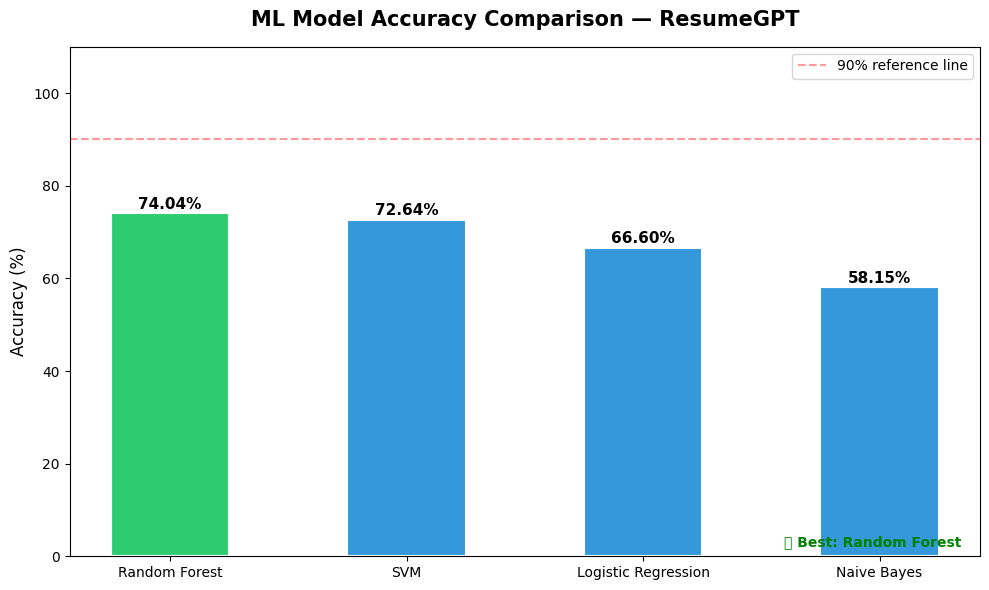

In [16]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

models = list(results_sorted.keys())
accuracies = [v * 100 for v in results_sorted.values()]

# Color the best model differently
colors = ['#2ecc71' if m == best_model_name else '#3498db' for m in models]

bars = ax.bar(models, accuracies, color=colors, edgecolor='white', linewidth=1.5, width=0.5)

# Add accuracy labels on top of bars
for bar, acc in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{acc:.2f}%',
        ha='center', va='bottom',
        fontweight='bold', fontsize=11
    )

ax.set_title('ML Model Accuracy Comparison — ResumeGPT', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(0, 110)
ax.axhline(y=90, color='red', linestyle='--', alpha=0.4, label='90% reference line')
ax.legend(fontsize=10)

# Add green label for best model
ax.text(0.98, 0.02, f'🏆 Best: {best_model_name}',
        transform=ax.transAxes, ha='right',
        fontsize=10, color='green', fontweight='bold')

plt.tight_layout()

save_path = project_path + "/assets/result_images/model_comparison.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()

In [17]:
# Save the best performing model so Day 5 can use it
best_model_map = {
    'Logistic Regression': lr_model,
    'Naive Bayes':         nb_model,
    'SVM':                 svm_model,
    'Random Forest':       rf_model
}

best_model_object = best_model_map[best_model_name]

# Save using pickle (same way we saved vectorizer on Day 3)
model_save_path = project_path + "/data/processed/best_model.pkl"

with open(model_save_path, 'wb') as f:
    pickle.dump(best_model_object, f)

# Also save all models for reference
all_models = {
    'logistic_regression': lr_model,
    'naive_bayes':         nb_model,
    'svm':                 svm_model,
    'random_forest':       rf_model
}

all_models_path = project_path + "/data/processed/all_models.pkl"
with open(all_models_path, 'wb') as f:
    pickle.dump(all_models, f)

# Save results as CSV for reference
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': list(results.values())
})
results_df.to_csv(project_path + "/data/processed/model_results.csv", index=False)

print("All models saved!")
print(f"Best model ({best_model_name}) saved to: {model_save_path}")

All models saved!
Best model (Random Forest) saved to: /content/drive/MyDrive/ResumeGPT/data/processed/best_model.pkl


In [18]:
# Load the vectorizer we saved on Day 3
with open(project_path + "/data/processed/tfidf_vectorizer.pkl", 'rb') as f:
    vectorizer = pickle.load(f)

# Pick a random resume from the test set and predict
import random
random.seed(42)

# Get the index of a test sample
test_indices = y_test.index.tolist()
sample_idx = random.choice(test_indices)

# Get the actual resume text and true category
sample_text = df.loc[sample_idx, 'cleaned_resume']
true_category = df.loc[sample_idx, 'Category']

# Transform using our vectorizer and predict
sample_vector = vectorizer.transform([sample_text])
predicted_category = best_model_object.predict(sample_vector)[0]

print("=== LIVE MODEL TEST ===")
print(f"Resume snippet  : {sample_text[:150]}...")
print(f"True Category   : {true_category}")
print(f"Model Predicted : {predicted_category}")

if predicted_category == true_category:
    print("✓ CORRECT PREDICTION!")
else:
    print("✗ Wrong prediction — but that's okay, no model is 100% perfect")

=== LIVE MODEL TEST ===
Resume snippet  : human resource professional professional summary experienced working fastpaced environment demanding strong organizational technical interpersonal ski...
True Category   : ADVOCATE
Model Predicted : HR
✗ Wrong prediction — but that's okay, no model is 100% perfect
